In [1]:
import pandas as pd
import warnings as ws

ws.filterwarnings('ignore')
dataset = pd.read_csv('Social_Network_Ads.csv')
dataset = pd.get_dummies(dataset, dtype=int, drop_first=True)

independent = dataset[['User ID', 'Age', 'EstimatedSalary', 'Gender_Male']]
dependent = dataset['Purchased']  # ← 1D array (no double brackets)

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    independent, dependent, test_size=0.30, random_state=0
)

print(dataset['Purchased'].value_counts())


Purchased
0    257
1    143
Name: count, dtype: int64


In [2]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(
    class_weight='balanced',   
    random_state=42
)
classifier.fit(X_train, Y_train)

Y_pred = classifier.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.94        79
           1       0.84      0.93      0.88        41

    accuracy                           0.92       120
   macro avg       0.90      0.92      0.91       120
weighted avg       0.92      0.92      0.92       120




ROC-AUC Score: 0.9648


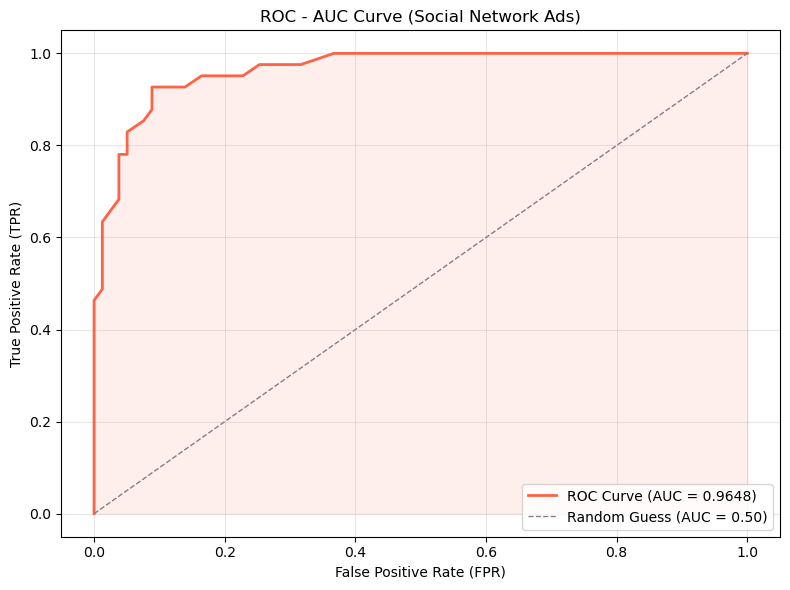

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Step 1 — Get probability scores for class 1 (Purchased)
Y_pred_proba = classifier.predict_proba(X_test)[:, 1]

# Step 2 — Calculate AUC score
auc_score = roc_auc_score(Y_test, Y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.4f}")

# Step 3 — Get FPR and TPR values for plotting
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)

# Step 4 — Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='tomato', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1,
         linestyle='--', label='Random Guess (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='tomato')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC - AUC Curve (Social Network Ads)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()